In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import torch
import gc
from pathlib import Path
import scanpy as sc
import pandas as pd
import copy
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon

import pandas as pd
from collections import Counter

from models import *
from count_FM_function_v3 import *
import ot
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)

device = cuda


In [2]:
def _get_ot_cost_matrix(x0, x1, ot_cost="none", ot_eps=1e-8):
    key = ot_cost.lower()

    if key == "none":
        return None
    if key == "l1":
        return (x0[:, None, :] - x1[None, :, :]).abs().sum(dim=2)
    if key == "l2":
        return torch.cdist(x0, x1, p=2) ** 2
    if key in {"sym_poisson", "symmetric_poisson", "symmetric-poisson", "poisson"}:
        A = x0[:, None, :].float()
        B = x1[None, :, :].float()
        d_ab = A * torch.log((A + ot_eps) / (B + ot_eps)) - A + B
        d_ba = B * torch.log((B + ot_eps) / (A + ot_eps)) - B + A
        return (d_ab + d_ba).sum(dim=2)

    raise ValueError(f"Unknown ot_cost: {ot_cost}")

def _soft_ot_pair_batch(
    x0,
    x1,
    ot_cost="none",
    ot_eps=1e-8,
    src_clusters=None,
    tgt_clusters=None,
    allowed_targets=None,
    big_cost=1e12,
):
    key = ot_cost.lower()
    if key == "none":
        return x0, x1

    B0 = x0.shape[0]
    B1 = x1.shape[0]

    M = _get_ot_cost_matrix(x0, x1, ot_cost=ot_cost, ot_eps=ot_eps)

    if (src_clusters is not None) and (tgt_clusters is not None) and (allowed_targets is not None):
        src_clusters = np.asarray(src_clusters).astype(str)
        tgt_clusters = np.asarray(tgt_clusters).astype(str)

        allowed = np.zeros((B0, B1), dtype=bool)
        for i, s in enumerate(src_clusters):
            allowed[i, :] = np.isin(tgt_clusters, list(allowed_targets[s]))

        if not allowed.any(axis=1).all():
            bad = np.where(~allowed.any(axis=1))[0]
            raise ValueError(f"Some source cells in this batch have no allowed targets: {src_clusters[bad].tolist()}")

        if not allowed.any(axis=0).all():
            bad = np.where(~allowed.any(axis=0))[0]
            raise ValueError(f"Some target cells in this batch have no allowed sources: {tgt_clusters[bad].tolist()}")

        allowed_t = torch.as_tensor(allowed, device=M.device, dtype=torch.bool)
        M = M.clone()
        finite_max = M[allowed_t].max() if allowed_t.any() else torch.tensor(0.0, device=M.device)
        M[~allowed_t] = finite_max + big_cost

    a = ot.unif(B0)
    b = ot.unif(B1)
    pi = ot.emd(a, b, M.detach().cpu().numpy())

    pi = np.asarray(pi, dtype=np.float64)
    if (not np.all(np.isfinite(pi))) or (pi.sum() <= 1e-12):
        p = np.ones(B0 * B1, dtype=np.float64) / float(B0 * B1)
    else:
        p = np.clip(pi, 0.0, None).reshape(-1)
        p = p / p.sum()

    choice = np.random.choice(B0 * B1, size=B1, replace=True, p=p)
    i_np, j_np = np.divmod(choice, B1)

    i = torch.as_tensor(i_np, device=x0.device, dtype=torch.long)
    j = torch.as_tensor(j_np, device=x1.device, dtype=torch.long)

    return x0[i], x1[j]


def _build_allowed_target_index_map(tgt_clusters, allowed_targets):
    tgt_clusters = np.asarray(tgt_clusters).astype(str)
    out = {}
    for src in sorted(allowed_targets):
        idx = np.where(np.isin(tgt_clusters, list(allowed_targets[src])))[0]
        out[src] = idx
    return out


def _sample_compatible_targets_for_sources(src_clusters_batch, allowed_target_index_map):
    src_clusters_batch = np.asarray(src_clusters_batch).astype(str)
    idx = np.empty(len(src_clusters_batch), dtype=np.int64)
    for i, s in enumerate(src_clusters_batch):
        pool = allowed_target_index_map[s]
        if len(pool) == 0:
            raise ValueError(f"No target cells available for source cluster {s}")
        idx[i] = np.random.choice(pool)
    return idx

@torch.no_grad()
def CountFM_eval(
    X1_torch,
    nets,
    batch_size,
    device,
    separate_heads=False,
    X0_torch=None,
    x0_mode="uniform",
    ot_cost="none",
    C_max=None,
    margin=2,
    eps_t=1e-4,
    eps_log=1e-8,
    loss_mode="poisson",
    X0_clusters=None,
    X1_clusters=None,
    allowed_targets=None,
    n_eval_batches=None,
):
    nets.eval()

    X1_torch = X1_torch.to(device)
    N1, d = X1_torch.shape

    if X0_torch is not None:
        X0_torch = X0_torch.to(device)
        N0 = X0_torch.shape[0]
    else:
        N0 = N1

    if C_max is None:
        C_max = int(X1_torch.max().item() + margin)

    if allowed_targets is not None:
        if X0_clusters is None or X1_clusters is None:
            raise ValueError("Need X0_clusters and X1_clusters when allowed_targets is used.")
        X0_clusters = np.asarray(X0_clusters).astype(str)
        X1_clusters = np.asarray(X1_clusters).astype(str)
        allowed_target_index_map = _build_allowed_target_index_map(X1_clusters, allowed_targets)
    else:
        allowed_target_index_map = None

    if n_eval_batches is None:
        n_eval_batches = max(1, (max(N0, N1) + batch_size - 1) // batch_size)

    losses = []

    for _ in range(n_eval_batches):
        if X0_torch is not None and x0_mode == "dataset":
            idx0 = torch.randint(0, N0, (batch_size,), device=device)
            x0 = X0_torch[idx0]
            src_clusters_batch = X0_clusters[idx0.detach().cpu().numpy()]
        elif x0_mode == "uniform":
            x0 = torch.randint(
                low=0,
                high=C_max + 1,
                size=(batch_size, d),
                device=device,
                dtype=X1_torch.dtype,
            )
            src_clusters_batch = None
        elif x0_mode == "poisson":
            x0 = torch.poisson(
                torch.full((batch_size, d), 1.0, device=device, dtype=torch.float32)
            ).to(X1_torch.dtype)
            src_clusters_batch = None
        else:
            raise ValueError(f"Unknown x0_mode: {x0_mode}")

        if (x0_mode == "dataset") and (allowed_target_index_map is not None):
            idx1_np = _sample_compatible_targets_for_sources(
                src_clusters_batch,
                allowed_target_index_map,
            )
            idx1 = torch.as_tensor(idx1_np, device=device, dtype=torch.long)
            x1 = X1_torch[idx1]
            tgt_clusters_batch = X1_clusters[idx1_np]
        else:
            idx1 = torch.randint(0, N1, (batch_size,), device=device)
            x1 = X1_torch[idx1]
            tgt_clusters_batch = None if X1_clusters is None else X1_clusters[idx1.detach().cpu().numpy()]

        x0, x1 = _soft_ot_pair_batch(
            x0,
            x1,
            ot_cost=ot_cost,
            ot_eps=eps_log,
            src_clusters=src_clusters_batch,
            tgt_clusters=tgt_clusters_batch,
            allowed_targets=allowed_targets,
        )

        B = x1.shape[0]
        t = torch.rand(B, 1, device=device) * (1.0 - 2.0 * eps_t) + eps_t
        xt = sample_xt(x0, x1, t)
        rates_star, idx_0 = sample_rt(xt, x1, t, eps_t)
        xt_t = torch.cat([xt, t], dim=1)
        rates_theta = model_forward(xt_t, separate_heads, nets, d, idx_0)
        loss = model_loss(loss_mode, rates_theta, rates_star, eps_log)
        losses.append(float(loss))

    return float(np.mean(losses))


def CountFM_train(
    X1_torch,
    nets,
    optimizer,
    num_epochs,
    batch_size,
    device,
    separate_heads=False,
    X0_torch=None,
    x0_mode="uniform",
    ot_cost="none",
    C_max=None,
    margin=2,
    eps_t=1e-4,
    eps_log=1e-8,
    loss_mode="poisson",
    X0_clusters=None,
    X1_clusters=None,
    allowed_targets=None,
    X1_val_torch=None,
    X0_val_torch=None,
    X0_clusters_val=None,
    X1_clusters_val=None,
    eval_every=5,
    patience=30,
    min_delta=1e-4,
    scheduler_factor=0.5,
    scheduler_patience=8,
    min_lr=1e-5,
    grad_clip=1.0,
    n_eval_batches=40,
):
    X1_torch = X1_torch.to(device)
    N1, d = X1_torch.shape

    if X0_torch is not None:
        X0_torch = X0_torch.to(device)
        N0 = X0_torch.shape[0]
    else:
        N0 = N1

    if C_max is None:
        C_max = int(X1_torch.max().item() + margin)

    if allowed_targets is not None:
        if X0_clusters is None or X1_clusters is None:
            raise ValueError("Need X0_clusters and X1_clusters when allowed_targets is used.")
        X0_clusters = np.asarray(X0_clusters).astype(str)
        X1_clusters = np.asarray(X1_clusters).astype(str)
        if len(X0_clusters) != N0:
            raise ValueError("len(X0_clusters) must equal len(X0_torch)")
        if len(X1_clusters) != N1:
            raise ValueError("len(X1_clusters) must equal len(X1_torch)")
        allowed_target_index_map = _build_allowed_target_index_map(X1_clusters, allowed_targets)
    else:
        allowed_target_index_map = None

    use_val = (X1_val_torch is not None)
    if use_val and allowed_targets is not None:
        X0_clusters_val = np.asarray(X0_clusters_val).astype(str)
        X1_clusters_val = np.asarray(X1_clusters_val).astype(str)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=scheduler_factor,
        patience=scheduler_patience,
        min_lr=min_lr,
    )

    best_metric = np.inf
    best_state = copy.deepcopy(nets.state_dict())
    best_epoch = -1
    bad_count = 0
    history = []

    steps_per_epoch = (max(N0, N1) + batch_size - 1) // batch_size

    for epoch in tqdm(range(num_epochs)):
        nets.train()

        if X0_torch is not None and x0_mode == "dataset":
            perm0 = torch.randperm(N0, device=device)
        else:
            perm0 = None

        train_losses = []

        for step in range(steps_per_epoch):
            start = step * batch_size
            base = torch.arange(batch_size, device=device)

            if X0_torch is not None and x0_mode == "dataset":
                idx0 = perm0[(start + base) % N0]
                x0 = X0_torch[idx0]
                src_clusters_batch = X0_clusters[idx0.detach().cpu().numpy()]
            elif x0_mode == "uniform":
                x0 = torch.randint(
                    low=0,
                    high=C_max + 1,
                    size=(batch_size, d),
                    device=device,
                    dtype=X1_torch.dtype,
                )
                src_clusters_batch = None
            elif x0_mode == "poisson":
                x0 = torch.poisson(
                    torch.full((batch_size, d), 1.0, device=device, dtype=torch.float32)
                ).to(X1_torch.dtype)
                src_clusters_batch = None
            else:
                raise ValueError(f"Unknown x0_mode: {x0_mode}")

            if (x0_mode == "dataset") and (allowed_target_index_map is not None):
                idx1_np = _sample_compatible_targets_for_sources(
                    src_clusters_batch,
                    allowed_target_index_map,
                )
                idx1 = torch.as_tensor(idx1_np, device=device, dtype=torch.long)
                x1 = X1_torch[idx1]
                tgt_clusters_batch = X1_clusters[idx1_np]
            else:
                idx1 = torch.randint(0, N1, (batch_size,), device=device)
                x1 = X1_torch[idx1]
                tgt_clusters_batch = None if X1_clusters is None else X1_clusters[idx1.detach().cpu().numpy()]

            x0, x1 = _soft_ot_pair_batch(
                x0,
                x1,
                ot_cost=ot_cost,
                ot_eps=eps_log,
                src_clusters=src_clusters_batch,
                tgt_clusters=tgt_clusters_batch,
                allowed_targets=allowed_targets,
            )

            B = x1.shape[0]
            t = torch.rand(B, 1, device=device) * (1.0 - 2.0 * eps_t) + eps_t
            xt = sample_xt(x0, x1, t)
            rates_star, idx_0 = sample_rt(xt, x1, t, eps_t)
            xt_t = torch.cat([xt, t], dim=1)
            rates_theta = model_forward(xt_t, separate_heads, nets, d, idx_0)
            loss = model_loss(loss_mode, rates_theta, rates_star, eps_log)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(nets.parameters(), grad_clip)
            optimizer.step()

            train_losses.append(float(loss))

        train_loss = float(np.mean(train_losses))

        if (epoch % eval_every == 0) or (epoch == num_epochs - 1):
            if use_val:
                monitor_loss = CountFM_eval(
                    X1_torch=X1_val_torch,
                    nets=nets,
                    batch_size=batch_size,
                    device=device,
                    separate_heads=separate_heads,
                    X0_torch=X0_val_torch,
                    x0_mode=x0_mode,
                    ot_cost=ot_cost,
                    C_max=C_max,
                    margin=margin,
                    eps_t=eps_t,
                    eps_log=eps_log,
                    loss_mode=loss_mode,
                    X0_clusters=X0_clusters_val,
                    X1_clusters=X1_clusters_val,
                    allowed_targets=allowed_targets,
                    n_eval_batches=n_eval_batches,
                )
            else:
                monitor_loss = train_loss

            scheduler.step(monitor_loss)
            lr_now = optimizer.param_groups[0]["lr"]

            history.append({
                "epoch": epoch,
                "train_loss": train_loss,
                "monitor_loss": monitor_loss,
                "lr": lr_now,
            })

            improved = monitor_loss < (best_metric - min_delta)
            if improved:
                best_metric = monitor_loss
                best_state = copy.deepcopy(nets.state_dict())
                best_epoch = epoch
                bad_count = 0
            else:
                bad_count += 1

            print(
                f"[ep {epoch}] train={train_loss:.6f}  "
                f"val={monitor_loss:.6f}  lr={lr_now:.2e}  "
                f"best={best_metric:.6f} @ {best_epoch}"
            )

            if bad_count >= patience:
                print(f"Early stop at ep {epoch}, restore best epoch {best_epoch}")
                break

    nets.load_state_dict(best_state)
    return nets, history, best_epoch, best_metric

In [3]:
def load_countfm_checkpoint(ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location=device)

    init_cfg = ckpt["model_init"]

    if init_cfg["base_name"] != "ChunkedAdaLNTransformer":
        raise ValueError(f"Unexpected base model: {init_cfg['base_name']}")
    if init_cfg["wrapper_name"] != "ChunkedAdaLNTransformer_rate":
        raise ValueError(f"Unexpected wrapper model: {init_cfg['wrapper_name']}")

    net_base = ChunkedAdaLNTransformer(
        **init_cfg["base_kwargs"]
    ).to(device)

    nets = ChunkedAdaLNTransformer_rate(
        net_base,
        **init_cfg["wrapper_kwargs"]
    ).to(device)

    nets.load_state_dict(ckpt["model_state_dict"])
    nets.eval()

    return nets, ckpt

# 1. Read Data

In [4]:
data_dir = Path("read_data/datasets/dentate_gyrus")
fp = next(data_dir.glob("*.h5ad"))
print("Loading:", fp)
adata = sc.read_h5ad(fp)
print(adata)

Loading: read_data/datasets/dentate_gyrus/DentateGyrus.h5ad
AnnData object with n_obs × n_vars = 2930 × 13913
    obs: 'age(days)', 'clusters', 'clusters_enlarged', 'index'
    var: 'index'
    obsm: 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'


# 2. Data Prep

In [5]:
np.random.seed(123)
torch.manual_seed(123)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(123)

# ----------------------------
# raw count matrix
# ----------------------------
X_layer = adata.layers["matrix"] if "matrix" in adata.layers else adata.X

if sp.issparse(X_layer):
    X1_np = X_layer.toarray().astype(np.float32)
else:
    X1_np = np.asarray(X_layer, dtype=np.float32)

print("X1_np shape:", X1_np.shape, "dtype:", X1_np.dtype)
print("min/max:", float(X1_np.min()), float(X1_np.max()))
print("integer_like:", np.allclose(X1_np, np.round(X1_np)))
print("nonnegative:", bool((X1_np >= 0).all()))

X1_torch = torch.tensor(X1_np, dtype=torch.float32)  # keep CPU
N1, d = X1_torch.shape
print("N1, d =", N1, d)

# ----------------------------
# final DG transport definition
# ----------------------------
cluster_col = "clusters"
age_col = "age(days)"

# broad branch label, mostly for inspection
TRANSPORT_BRANCH = {
    "Radial Glia-like": "granule",
    "nIPC": "granule",
    "Neuroblast": "granule",
    "Granule immature": "granule",
    "Granule mature": "granule",
    "Astrocytes": "astro",
    "OPC": "opc_ol",
    "OL": "opc_ol",
    "Cajal Retzius": "side",
    "Cck-Tox": "side",
    "Endothelial": "side",
    "GABA": "side",
    "Microglia": "side",
    "Mossy": "side",
}

# directed endpoint targets for age12 -> age35 transport
# this is the important object, not the broad branch label
ALLOWED_TARGETS = {
    "Radial Glia-like": {
        "Radial Glia-like",
        "nIPC",
        "Neuroblast",
        "Granule immature",
        "Granule mature",
        "Astrocytes",
    },
    "nIPC": {
        "nIPC",
        "Neuroblast",
        "Granule immature",
        "Granule mature",
        "Astrocytes",
    },
    "Neuroblast": {
        "Neuroblast",
        "Granule immature",
        "Granule mature",
    },
    "Granule immature": {
        "Granule immature",
        "Granule mature",
    },
    "Granule mature": {
        "Granule mature",
    },
    "Astrocytes": {
        "Astrocytes",
    },
    "OPC": {
        "OPC",
        "OL",
    },
    "OL": {
        "OL",
    },
    "Cajal Retzius": {
        "Cajal Retzius",
    },
    "Cck-Tox": {
        "Cck-Tox",
    },
    "Endothelial": {
        "Endothelial",
    },
    "GABA": {
        "GABA",
    },
    "Microglia": {
        "Microglia",
    },
    "Mossy": {
        "Mossy",
    },
}

obs_clusters = sorted(adata.obs[cluster_col].astype(str).unique().tolist())

missing_branch = [c for c in obs_clusters if c not in TRANSPORT_BRANCH]
missing_targets = [c for c in obs_clusters if c not in ALLOWED_TARGETS]

if len(missing_branch) > 0:
    raise ValueError(f"Missing in TRANSPORT_BRANCH: {missing_branch}")
if len(missing_targets) > 0:
    raise ValueError(f"Missing in ALLOWED_TARGETS: {missing_targets}")

bad_targets = {
    src: sorted(list(set(tgts) - set(obs_clusters)))
    for src, tgts in ALLOWED_TARGETS.items()
    if len(set(tgts) - set(obs_clusters)) > 0
}
if len(bad_targets) > 0:
    raise ValueError(f"Unknown targets in ALLOWED_TARGETS: {bad_targets}")

adata.obs["transport_branch"] = (
    adata.obs[cluster_col].astype(str).map(TRANSPORT_BRANCH)
)

print("\ncluster x age")
print(pd.crosstab(adata.obs[cluster_col].astype(str), adata.obs[age_col].astype(str)))

print("\ntransport_branch x age")
print(pd.crosstab(adata.obs["transport_branch"].astype(str), adata.obs[age_col].astype(str)))

# cluster-level allowed endpoint matrix
src_clusters = sorted(adata.obs.loc[adata.obs[age_col].astype(str) == "12", cluster_col].astype(str).unique().tolist())
tgt_clusters = sorted(adata.obs.loc[adata.obs[age_col].astype(str) == "35", cluster_col].astype(str).unique().tolist())

allowed_cluster_matrix = pd.DataFrame(
    0,
    index=src_clusters,
    columns=tgt_clusters,
    dtype=int,
)
for src in src_clusters:
    allowed_cluster_matrix.loc[src, list(ALLOWED_TARGETS[src] & set(tgt_clusters))] = 1

print("\nallowed endpoint cluster matrix")
print(allowed_cluster_matrix)

X1_np shape: (2930, 13913) dtype: float32
min/max: 0.0 1718.0
integer_like: True
nonnegative: True
N1, d = 2930 13913

cluster x age
age(days)          12    35
clusters                   
Astrocytes         56    64
Cajal Retzius      17    17
Cck-Tox             1    26
Endothelial        34    53
GABA               34    27
Granule immature  420   365
Granule mature     59  1011
Microglia          30    51
Mossy              48    27
Neuroblast        350    67
OL                  1    49
OPC                28    25
Radial Glia-like   35    16
nIPC               11     8

transport_branch x age
age(days)          12    35
transport_branch           
astro              56    64
granule           875  1467
opc_ol             29    74
side              164   201

allowed endpoint cluster matrix
                  Astrocytes  Cajal Retzius  Cck-Tox  Endothelial  GABA  \
Astrocytes                 1              0        0            0     0   
Cajal Retzius              0              1 

# 3. Model

In [6]:
separate_heads = False

net_base = ChunkedAdaLNTransformer(
    dim=d,
    out_dim=2*d,
    time_varying=True,
    d_model=256,
    depth=8,
    n_heads=8,
    mlp_ratio=4.0,
    dropout=0.0,
    chunk_size=128,
).to(device)

In [7]:
nets = ChunkedAdaLNTransformer_rate(net_base).to(device)
n_params = sum(p.numel() for p in nets.parameters())

print("model params =", n_params)

model params = 9857792


# 4. Training

In [8]:
age = adata.obs["age(days)"].astype(str).values
clusters = adata.obs["clusters"].astype(str).values

rng = np.random.default_rng(123)

def stratified_split_by_cluster(age_value, train_frac=0.8):
    idx_age = np.where(age == age_value)[0]
    cl_age = clusters[idx_age]

    idx_tr_list = []
    idx_te_list = []

    for cl in sorted(np.unique(cl_age)):
        idx_cl = idx_age[cl_age == cl]
        idx_cl = idx_cl.copy()
        rng.shuffle(idx_cl)

        n_cl = len(idx_cl)
        if n_cl <= 1:
            idx_tr_cl = idx_cl
            idx_te_cl = np.array([], dtype=int)
        else:
            n_tr_cl = max(1, int(round(train_frac * n_cl)))
            n_tr_cl = min(n_tr_cl, n_cl - 1)
            idx_tr_cl = idx_cl[:n_tr_cl]
            idx_te_cl = idx_cl[n_tr_cl:]

        idx_tr_list.append(idx_tr_cl)
        idx_te_list.append(idx_te_cl)

    idx_tr = np.concatenate(idx_tr_list)
    idx_te = np.concatenate(idx_te_list)

    rng.shuffle(idx_tr)
    rng.shuffle(idx_te)
    return idx_tr, idx_te

idx12_tr, idx12_te = stratified_split_by_cluster("12", train_frac=0.8)
idx35_tr, idx35_te = stratified_split_by_cluster("35", train_frac=0.8)

print("age12 train/test:", len(idx12_tr), len(idx12_te))
print("age35 train/test:", len(idx35_tr), len(idx35_te))

print("\nAge12 train cluster counts")
print(pd.Series(clusters[idx12_tr]).value_counts().sort_index())

print("\nAge12 test cluster counts")
print(pd.Series(clusters[idx12_te]).value_counts().sort_index())

print("\nAge35 train cluster counts")
print(pd.Series(clusters[idx35_tr]).value_counts().sort_index())

print("\nAge35 test cluster counts")
print(pd.Series(clusters[idx35_te]).value_counts().sort_index())

age12 train/test: 899 225
age35 train/test: 1446 360

Age12 train cluster counts
Astrocytes           45
Cajal Retzius        14
Cck-Tox               1
Endothelial          27
GABA                 27
Granule immature    336
Granule mature       47
Microglia            24
Mossy                38
Neuroblast          280
OL                    1
OPC                  22
Radial Glia-like     28
nIPC                  9
Name: count, dtype: int64

Age12 test cluster counts
Astrocytes          11
Cajal Retzius        3
Endothelial          7
GABA                 7
Granule immature    84
Granule mature      12
Microglia            6
Mossy               10
Neuroblast          70
OPC                  6
Radial Glia-like     7
nIPC                 2
Name: count, dtype: int64

Age35 train cluster counts
Astrocytes           51
Cajal Retzius        14
Cck-Tox              21
Endothelial          42
GABA                 22
Granule immature    292
Granule mature      809
Microglia            41
Mossy   

In [9]:
X0_tr = torch.from_numpy(X1_np[idx12_tr]).float()
X1_tr = torch.from_numpy(X1_np[idx35_tr]).float()
X0_te = torch.from_numpy(X1_np[idx12_te]).float()
X1_te = torch.from_numpy(X1_np[idx35_te]).float()

In [10]:
cl_all = adata.obs["clusters"].astype(str).values

cl12_tr = cl_all[idx12_tr]
cl35_tr = cl_all[idx35_tr]
cl12_te = cl_all[idx12_te]
cl35_te = cl_all[idx35_te]

print("P12 train clusters")
print(pd.Series(cl12_tr).value_counts())

print("\nP35 train clusters")
print(pd.Series(cl35_tr).value_counts())

print("\nAllowed targets by source cluster")
for k in sorted(ALLOWED_TARGETS):
    print(f"{k:18s} -> {sorted(ALLOWED_TARGETS[k])}")

P12 train clusters
Granule immature    336
Neuroblast          280
Granule mature       47
Astrocytes           45
Mossy                38
Radial Glia-like     28
GABA                 27
Endothelial          27
Microglia            24
OPC                  22
Cajal Retzius        14
nIPC                  9
OL                    1
Cck-Tox               1
Name: count, dtype: int64

P35 train clusters
Granule mature      809
Granule immature    292
Neuroblast           54
Astrocytes           51
Endothelial          42
Microglia            41
OL                   39
Mossy                22
GABA                 22
Cck-Tox              21
OPC                  20
Cajal Retzius        14
Radial Glia-like     13
nIPC                  6
Name: count, dtype: int64

Allowed targets by source cluster
Astrocytes         -> ['Astrocytes']
Cajal Retzius      -> ['Cajal Retzius']
Cck-Tox            -> ['Cck-Tox']
Endothelial        -> ['Endothelial']
GABA               -> ['GABA']
Granule immature   -> 

In [11]:
lr = 1e-3
optimizer = torch.optim.AdamW(nets.parameters(), lr=lr)

In [12]:
CKPT_PATH = Path("checkpoints") / "countfm_age12_to_35_masked_ot.pt"
nets_loaded, ckpt_loaded = load_countfm_checkpoint(CKPT_PATH, device)

print("loaded from:", CKPT_PATH)
print("best_epoch:", ckpt_loaded["best_epoch"])
print("best_val  :", ckpt_loaded["best_val"])

optimizer = torch.optim.AdamW(nets_loaded.parameters(), lr=1e-3)
optimizer.load_state_dict(ckpt_loaded["optimizer_state_dict"])

nets = nets_loaded
hist = ckpt_loaded["hist"]
best_epoch = ckpt_loaded["best_epoch"]
best_val = ckpt_loaded["best_val"]

loaded from: checkpoints/countfm_age12_to_35_masked_ot.pt
best_epoch: 120
best_val  : 2897.3369567871096


In [13]:
batch_size = 32
num_epochs = 5000
eps_t = 1e-4
eps_log = 1e-8
loss_mode = "poisson"
margin = 2

# nets.train()
# nets, hist, best_epoch, best_val = CountFM_train(
#     X1_torch=X1_tr,
#     nets=nets,
#     optimizer=optimizer,
#     num_epochs=num_epochs,
#     batch_size=batch_size,
#     device=device,
#     separate_heads=separate_heads,
#     X0_torch=X0_tr,
#     x0_mode="dataset",
#     ot_cost="sym_poisson",
#     margin=margin,
#     eps_t=eps_t,
#     eps_log=eps_log,
#     loss_mode=loss_mode,
#     X0_clusters=cl12_tr,
#     X1_clusters=cl35_tr,
#     allowed_targets=ALLOWED_TARGETS,
#     X1_val_torch=X1_te,
#     X0_val_torch=X0_te,
#     X0_clusters_val=cl12_te,
#     X1_clusters_val=cl35_te,
#     eval_every=5,
#     patience=30,
#     min_delta=1e-4,
#     scheduler_factor=0.5,
#     scheduler_patience=8,
#     min_lr=1e-5,
#     grad_clip=1.0,
#     n_eval_batches=40,
# )

print("best_epoch =", best_epoch)
print("best_val   =", best_val)

best_epoch = 120
best_val   = 2897.3369567871096


In [14]:
# CKPT_DIR = Path("checkpoints")
# CKPT_DIR.mkdir(parents=True, exist_ok=True)
# CKPT_PATH = CKPT_DIR / "countfm_age12_to_35_masked_ot.pt"

# ckpt = {
#     "model_state_dict": nets.state_dict(),
#     "optimizer_state_dict": optimizer.state_dict(),
#     "hist": hist,
#     "best_epoch": best_epoch,
#     "best_val": best_val,
#     "model_init": {
#         "base_name": "ChunkedAdaLNTransformer",
#         "base_kwargs": {
#             "dim": d,
#             "out_dim": 2 * d,
#             "time_varying": True,
#             "d_model": 256,
#             "depth": 8,
#             "n_heads": 8,
#             "mlp_ratio": 4.0,
#             "dropout": 0.0,
#             "chunk_size": 128,
#         },
#         "wrapper_name": "ChunkedAdaLNTransformer_rate",
#         "wrapper_kwargs": {
#             "log_cap": 12.0,
#             "eps": 1e-8,
#         },
#         "separate_heads": separate_heads,
#     },
#     "train_meta": {
#         "batch_size": batch_size,
#         "num_epochs": num_epochs,
#         "eps_t": eps_t,
#         "eps_log": eps_log,
#         "loss_mode": loss_mode,
#         "margin": margin,
#         "ot_cost": "sym_poisson",
#         "lr": optimizer.param_groups[0]["lr"],
#     },
# }
# torch.save(ckpt, CKPT_PATH)
# print("saved to:", CKPT_PATH)

,epoch,train_loss,monitor_loss,lr
50,250,2270.020640,3190.194257,0.000125
51,255,2248.844900,3168.242719,0.000063
52,260,2060.076256,3115.934883,0.000063
53,265,2063.112517,3152.425992,0.000063
54,270,2442.254068,3040.806692,0.000063


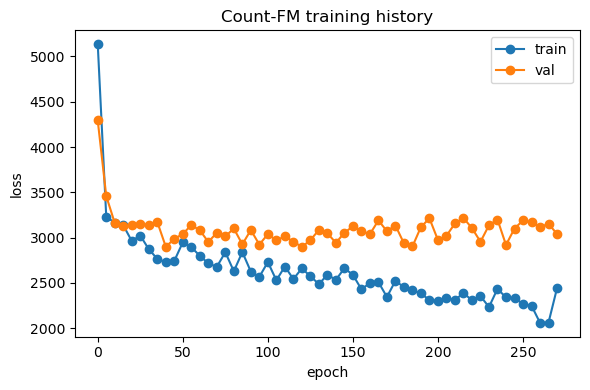

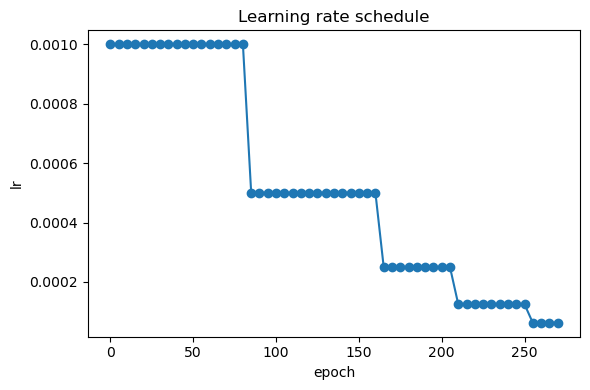

In [15]:
hist_df = pd.DataFrame(hist)
display(hist_df.tail())

plt.figure(figsize=(6, 4))
plt.plot(hist_df["epoch"], hist_df["train_loss"], marker="o", label="train")
plt.plot(hist_df["epoch"], hist_df["monitor_loss"], marker="o", label="val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Count-FM training history")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(hist_df["epoch"], hist_df["lr"], marker="o")
plt.xlabel("epoch")
plt.ylabel("lr")
plt.title("Learning rate schedule")
plt.tight_layout()
plt.show()

# 5. Generation

In [16]:
@torch.no_grad()
def sample_euler_batched_with_snaps(
    nets, n_step, x0_cpu, device,
    batch_eval=32, eps_t=1e-4, eps_log=1e-8, separate_heads=False,
    snap_ids=None, snap_n=0
):
    nets.eval()
    N, d = x0_cpu.shape

    if snap_ids is None or snap_n <= 0:
        snap_set = set()
        snap_ids = []
    else:
        snap_ids = sorted(set(int(s) for s in snap_ids))
        snap_set = set(snap_ids)

    snaps = {}
    if snap_set:
        for s in snap_ids:
            snaps[s] = torch.empty((snap_n, d), dtype=torch.float32, device="cpu")

    outs = []
    Delta = (1.0 - 2.0 * eps_t) / float(n_step)
    Delta_t = torch.tensor(Delta, device=device, dtype=torch.float32)

    for start in range(0, N, batch_eval):
        end = min(start + batch_eval, N)
        xt = x0_cpu[start:end].to(device=device, dtype=torch.float32).clone()
        B = xt.shape[0]
        t = torch.full((B, 1), eps_t, device=device, dtype=torch.float32)

        # step 0 snapshot
        if 0 in snap_set and start < snap_n:
            take = min(end, snap_n) - start
            if take > 0:
                snaps[0][start:start+take] = xt[:take].detach().cpu()

        for k in range(1, n_step + 1):
            xt_t = torch.cat([xt, t], dim=1)

            if not separate_heads:
                out = nets(xt_t)
                lambda_theta, beta_theta = out[:, :d], out[:, d:]
            else:
                lambda_theta = nets[0](xt_t)
                beta_theta   = nets[1](xt_t)

            idx_0 = (xt <= 0).to(torch.float32)
            mu_theta = (xt * beta_theta) * (1.0 - idx_0)

            r_i = lambda_theta + mu_theta
            p_none  = torch.exp(-r_i * Delta_t)
            p_jump  = 1.0 - p_none
            p_birth = p_jump * (lambda_theta / (r_i + eps_log))
            p_death = p_jump * (mu_theta     / (r_i + eps_log))

            probs3 = torch.stack([p_none, p_birth, p_death], dim=-1)
            choice = torch.multinomial(probs3.reshape(-1, 3), 1).view(B, d)

            adj = (choice == 1).to(torch.float32) - (choice == 2).to(torch.float32)
            xt = torch.clamp(xt + adj, min=0.0)

            t = torch.minimum(t + Delta_t, torch.full_like(t, 1.0 - eps_t))
            if k in snap_set and start < snap_n:
                take = min(end, snap_n) - start
                if take > 0:
                    snaps[k][start:start+take] = xt[:take].detach().cpu()

        outs.append(xt.to(torch.long).cpu())

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    x1_all = torch.cat(outs, dim=0)
    return x1_all, snaps

In [17]:
n_step_eval = 500
batch_eval = 32

# sparse times for the 2x3 snapshot panels
t_show_panel = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], dtype=np.float32)

# denser times for trajectory plotting only
t_show_traj = np.linspace(0.0, 1.0, 21, dtype=np.float32)

# sample once, using the union of all needed times
t_show_all = np.unique(np.concatenate([t_show_panel, t_show_traj]))
snap_ids_all = np.clip(np.round(t_show_all * n_step_eval).astype(int), 0, n_step_eval)

N_vis = 2000

X0_tr_map = X0_tr.clone()
X0_te_map = X0_te.clone()

print("t_show_panel:", t_show_panel)
print("t_show_traj :", t_show_traj)
print("snap_ids_all:", snap_ids_all, "N_vis", N_vis)

t_show_panel: [0.  0.2 0.4 0.6 0.8 1. ]
t_show_traj : [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
snap_ids_all: [  0  25  50  75 100 125 150 175 200 225 250 275 300 325 350 375 400 425
 450 475 500] N_vis 2000


In [18]:
x1_tr_gen, snaps_tr = sample_euler_batched_with_snaps(
    nets=nets,
    n_step=n_step_eval,
    x0_cpu=X0_tr_map,
    device=device,
    batch_eval=batch_eval,
    eps_t=eps_t,
    eps_log=eps_log,
    separate_heads=separate_heads,
    snap_ids=snap_ids_all,
    snap_n=min(N_vis, X0_tr_map.shape[0]),
)

x1_te_gen, snaps_te = sample_euler_batched_with_snaps(
    nets=nets,
    n_step=n_step_eval,
    x0_cpu=X0_te_map,
    device=device,
    batch_eval=batch_eval,
    eps_t=eps_t,
    eps_log=eps_log,
    separate_heads=separate_heads,
    snap_ids=snap_ids_all,
    snap_n=min(N_vis, X0_te_map.shape[0]),
)


In [19]:
traj_snap_tr_counts = np.stack([snaps_tr[int(s)].numpy() for s in snap_ids_all], axis=0)
traj_snap_tr_panel_counts = np.stack(
    [snaps_tr[int(s)].numpy() for s in np.clip(np.round(t_show_panel * n_step_eval).astype(int), 0, n_step_eval)],
    axis=0,
)

print("x1_tr_gen shape:", tuple(x1_tr_gen.shape))
print("traj_snap_tr_counts shape:", traj_snap_tr_counts.shape)
print("traj_snap_tr_panel_counts shape:", traj_snap_tr_panel_counts.shape)

traj_snap_te_counts = np.stack([snaps_te[int(s)].numpy() for s in snap_ids_all], axis=0)
traj_snap_te_panel_counts = np.stack(
    [snaps_te[int(s)].numpy() for s in np.clip(np.round(t_show_panel * n_step_eval).astype(int), 0, n_step_eval)],
    axis=0,
)

print("x1_te_gen shape:", tuple(x1_te_gen.shape))
print("traj_snap_te_counts shape:", traj_snap_te_counts.shape)
print("traj_snap_te_panel_counts shape:", traj_snap_te_panel_counts.shape)

x1_tr_gen shape: (899, 13913)
traj_snap_tr_counts shape: (21, 899, 13913)
traj_snap_tr_panel_counts shape: (6, 899, 13913)
x1_te_gen shape: (225, 13913)
traj_snap_te_counts shape: (21, 225, 13913)
traj_snap_te_panel_counts shape: (6, 225, 13913)


# 6. PCA

In [20]:
def log1p_libnorm_np(X, target_sum=1e4):
    X = X.astype(np.float32, copy=False)
    lib = X.sum(axis=1, keepdims=True).astype(np.float32)
    lib = np.maximum(lib, 1.0)
    Xn = X * (target_sum / lib)
    return np.log1p(Xn)

def fit_pca(X_real_counts, g_keep=256):
    X_log = log1p_libnorm_np(X_real_counts)
    g_keep = min(g_keep, X_log.shape[1])
    top_idx = np.argsort(X_log.var(axis=0))[-g_keep:]
    R = X_log[:, top_idx]
    center = R.mean(axis=0)
    _, _, Vt = np.linalg.svd(R - center[None, :], full_matrices=False)
    W = Vt[:2].T
    return top_idx, center.astype(np.float32), W.astype(np.float32)

def proj2(X_counts, top_idx, center, W):
    X_log = log1p_libnorm_np(X_counts)
    X_sel = X_log[:, top_idx]
    return (X_sel - center[None, :]) @ W

def proj2_traj(traj_counts, top_idx, center, W):
    K, B, d_ = traj_counts.shape
    flat = traj_counts.reshape(K * B, d_)
    flat2 = proj2(flat, top_idx, center, W)
    return flat2.reshape(K, B, 2)

In [21]:
# global reference for fate assignment
ref_np_all = X1_np.astype(np.float32, copy=False)
ref_clusters_all = adata.obs["clusters"].astype(str).values

# use all real cells to define the PCA basis for fate calling
pca_top_idx_all, pca_center_all, pca_W_all = fit_pca(ref_np_all, g_keep=256)
ref_2d_all = proj2(ref_np_all, pca_top_idx_all, pca_center_all, pca_W_all)

print("ref_np_all shape:", ref_np_all.shape)
print("ref_2d_all shape:", ref_2d_all.shape)

ref_np_all shape: (2930, 13913)
ref_2d_all shape: (2930, 2)


In [22]:
def _cluster_order_present(labels):
    base_order = [
        "Radial Glia-like",
        "nIPC",
        "Neuroblast",
        "Granule immature",
        "Granule mature",
        "Astrocytes",
        "OPC",
        "OL",
        "Cajal Retzius",
        "Cck-Tox",
        "Endothelial",
        "GABA",
        "Microglia",
        "Mossy",
    ]
    labels = set(pd.Series(labels).astype(str).unique().tolist())
    return [x for x in base_order if x in labels]

In [23]:
def plot_cluster_trajectories_pca(
    src_2d,
    tgt_2d,
    traj_2d,
    src_clusters_all,
    tgt_clusters_all,
    src_clusters_snap,
    t_show,
    title,
    min_n=20,
    traj_alpha=0.10,
    traj_lw=0.8,
    arrow_alpha=0.55,
    arrow_frac=(0.70,),
    arrow_every=3,
    endpoint_arrow=True,
    head_len=0.35,        # elongated arrowhead length in PCA units
    head_w=0.12,          # arrowhead half width in PCA units
):
    src_clusters_all = pd.Series(src_clusters_all).astype(str).values
    tgt_clusters_all = pd.Series(tgt_clusters_all).astype(str).values
    src_clusters_snap = pd.Series(src_clusters_snap).astype(str).values

    cluster_order = _cluster_order_present(
        np.concatenate([src_clusters_all, tgt_clusters_all, src_clusters_snap])
    )

    cmap = plt.get_cmap("tab20")
    color_map = {k: cmap(i % 20) for i, k in enumerate(cluster_order)}

    fig, ax = plt.subplots(figsize=(8, 7))

    # background true data, colored by cluster
    for k in cluster_order:
        src_idx = (src_clusters_all == k)
        tgt_idx = (tgt_clusters_all == k)

        if src_idx.sum() > 0:
            ax.scatter(
                src_2d[src_idx, 0],
                src_2d[src_idx, 1],
                s=14,
                alpha=0.32,
                color=color_map[k],
                edgecolors="none",
            )

        if tgt_idx.sum() > 0:
            ax.scatter(
                tgt_2d[tgt_idx, 0],
                tgt_2d[tgt_idx, 1],
                s=20,
                alpha=0.50,
                color=color_map[k],
                marker="x",
                linewidths=1.0,
            )

    T = traj_2d.shape[0]

    inner_steps = []
    for frac in arrow_frac:
        s = int(round(frac * (T - 1)))
        s = max(1, min(T - 1, s))
        inner_steps.append(s)
    inner_steps = sorted(set(inner_steps))

    def _draw_arrowhead_only(ax, p0, p1, alpha, head_len, head_w):
        x0, y0 = p0
        x1, y1 = p1
        dx = x1 - x0
        dy = y1 - y0
        norm = np.hypot(dx, dy)
        if norm < 1e-12:
            return

        ux, uy = dx / norm, dy / norm
        px, py = -uy, ux

        tip = np.array([x1, y1])
        base = tip - head_len * np.array([ux, uy])
        left = base + head_w * np.array([px, py])
        right = base - head_w * np.array([px, py])

        patch = Polygon(
            [tip, left, right],
            closed=True,
            facecolor="black",
            edgecolor="none",
            alpha=alpha,
            zorder=4,
        )
        ax.add_patch(patch)

    # trajectories in gray, arrowheads only
    for k in cluster_order:
        idx = np.where(src_clusters_snap == k)[0]
        if len(idx) < min_n:
            continue

        for m, j in enumerate(idx):
            path = traj_2d[:, j, :]

            ax.plot(
                path[:, 0],
                path[:, 1],
                color="black",
                alpha=traj_alpha,
                linewidth=traj_lw,
            )

            # internal arrowheads for only a subset
            if (m % arrow_every) == 0:
                for s in inner_steps:
                    _draw_arrowhead_only(
                        ax,
                        path[s - 1],
                        path[s],
                        alpha=arrow_alpha * 0.8,
                        head_len=head_len,
                        head_w=head_w,
                    )

            # endpoint arrowhead always present
            if endpoint_arrow and T >= 2:
                _draw_arrowhead_only(
                    ax,
                    path[-2],
                    path[-1],
                    alpha=arrow_alpha,
                    head_len=head_len,
                    head_w=head_w,
                )

    # legend only for colors
    handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=color_map[k],
            markeredgecolor="black",
            markersize=7,
            label=k,
        )
        for k in cluster_order
    ]
    ax.legend(handles=handles, loc="best", fontsize=8, ncol=2, title="cluster")

    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    plt.tight_layout()
    plt.show()

## train

In [24]:
src_np_tr = X0_tr.detach().cpu().numpy().astype(np.float32, copy=False)
tgt_np_tr = X1_tr.detach().cpu().numpy().astype(np.float32, copy=False)
gen_np_tr = x1_tr_gen.detach().cpu().numpy().astype(np.float32, copy=False)

src_2d_tr = proj2(src_np_tr, pca_top_idx_all, pca_center_all, pca_W_all)
tgt_2d_tr = proj2(tgt_np_tr, pca_top_idx_all, pca_center_all, pca_W_all)
gen_2d_tr = proj2(gen_np_tr, pca_top_idx_all, pca_center_all, pca_W_all)
traj_2d_tr = proj2_traj(traj_snap_tr_counts, pca_top_idx_all, pca_center_all, pca_W_all)

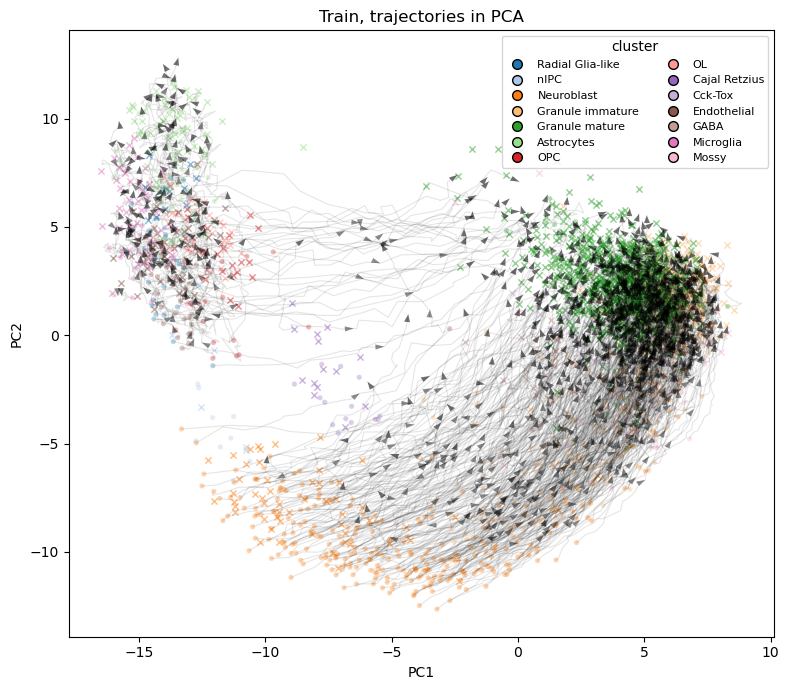

In [25]:
src_clusters_snap_tr = cl12_tr[:traj_2d_tr.shape[1]]

plot_cluster_trajectories_pca(
    src_2d=src_2d_tr,
    tgt_2d=tgt_2d_tr,
    traj_2d=traj_2d_tr,
    src_clusters_all=cl12_tr,
    tgt_clusters_all=cl35_tr,
    src_clusters_snap=src_clusters_snap_tr,
    t_show=t_show_all,
    title="Train, trajectories in PCA",
    min_n=20,
    arrow_frac=(0.5,),
    arrow_every=2,
)

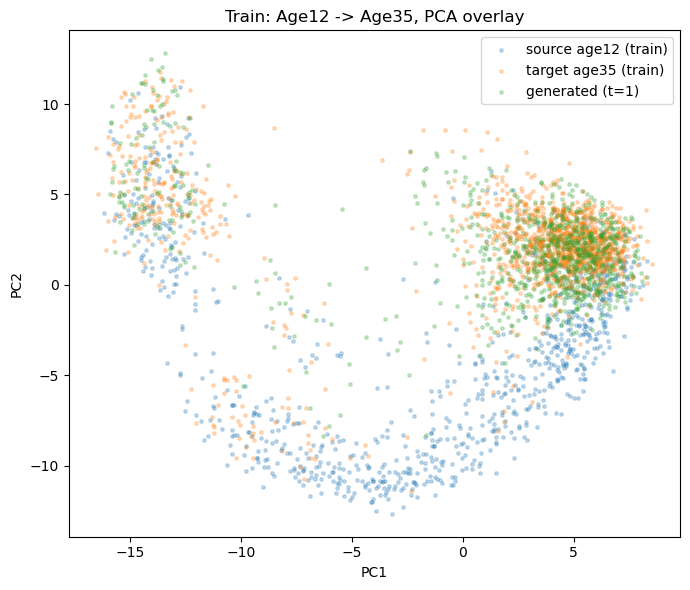

In [26]:
plt.figure(figsize=(7, 6))
plt.scatter(src_2d_tr[:, 0], src_2d_tr[:, 1], s=6, alpha=0.25, label="source age12 (train)")
plt.scatter(tgt_2d_tr[:, 0], tgt_2d_tr[:, 1], s=6, alpha=0.25, label="target age35 (train)")
plt.scatter(gen_2d_tr[:, 0], gen_2d_tr[:, 1], s=6, alpha=0.25, label="generated (t=1)")
plt.title("Train: Age12 -> Age35, PCA overlay")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

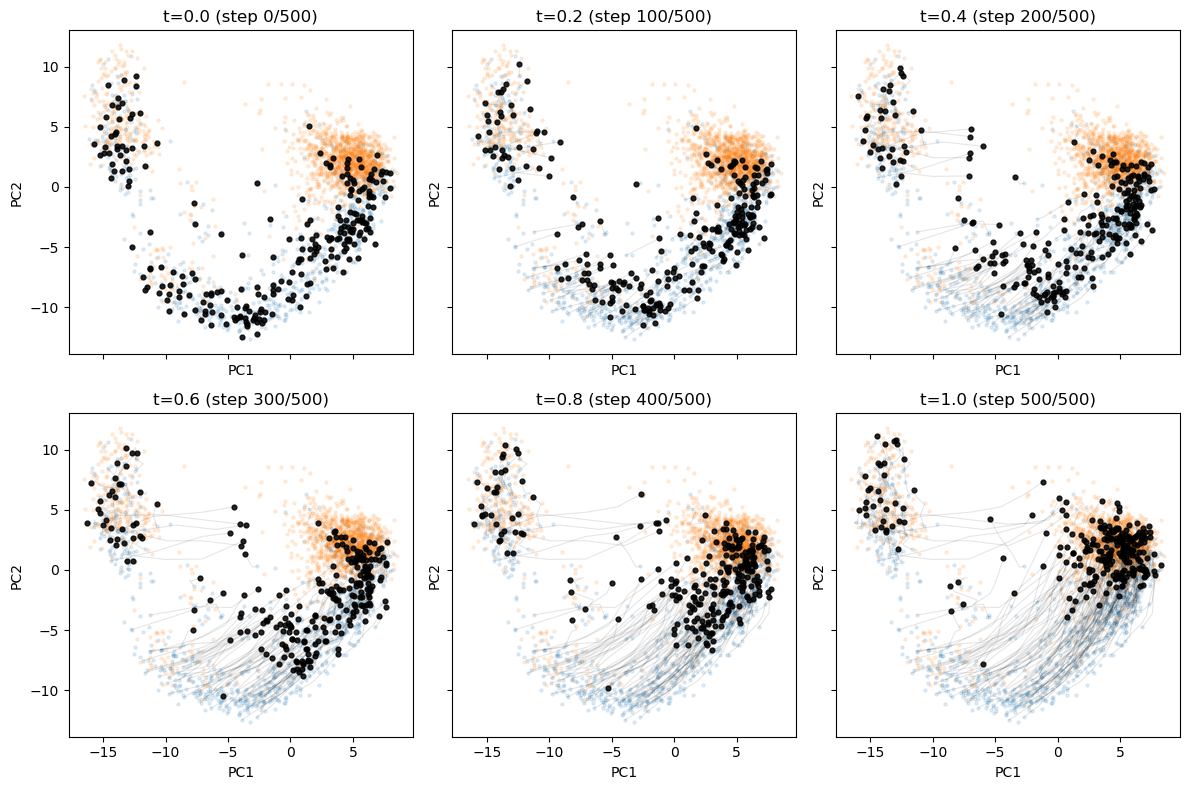

In [27]:
traj_panel_2d_tr = proj2_traj(traj_snap_tr_panel_counts, pca_top_idx_all, pca_center_all, pca_W_all)
snap_ids_panel = np.clip(np.round(t_show_panel * n_step_eval).astype(int), 0, n_step_eval)

rng = np.random.default_rng(123)
N_tail = min(250, traj_panel_2d_tr.shape[1])
idx_tail = rng.choice(traj_panel_2d_tr.shape[1], size=N_tail, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()

for j, ax in enumerate(axes):
    ax.scatter(src_2d_tr[:, 0], src_2d_tr[:, 1], s=5, alpha=0.12, color="tab:blue")
    ax.scatter(tgt_2d_tr[:, 0], tgt_2d_tr[:, 1], s=5, alpha=0.12, color="tab:orange")
    for i in idx_tail:
        path = traj_panel_2d_tr[:j+1, i, :]
        ax.plot(path[:, 0], path[:, 1], color="black", alpha=0.10, linewidth=0.8)
    ax.scatter(traj_panel_2d_tr[j, idx_tail, 0], traj_panel_2d_tr[j, idx_tail, 1], s=12, alpha=0.85, color="black")
    ax.set_title(f"t={t_show_panel[j]:.1f} (step {snap_ids_panel[j]}/{n_step_eval})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

## test

In [28]:
src_np_te = X0_te.detach().cpu().numpy().astype(np.float32, copy=False)
tgt_np_te = X1_te.detach().cpu().numpy().astype(np.float32, copy=False)
gen_np_te = x1_te_gen.detach().cpu().numpy().astype(np.float32, copy=False)

src_2d_te = proj2(src_np_te, pca_top_idx_all, pca_center_all, pca_W_all)
tgt_2d_te = proj2(tgt_np_te, pca_top_idx_all, pca_center_all, pca_W_all)
gen_2d_te = proj2(gen_np_te, pca_top_idx_all, pca_center_all, pca_W_all)
traj_2d_te = proj2_traj(traj_snap_te_counts, pca_top_idx_all, pca_center_all, pca_W_all)

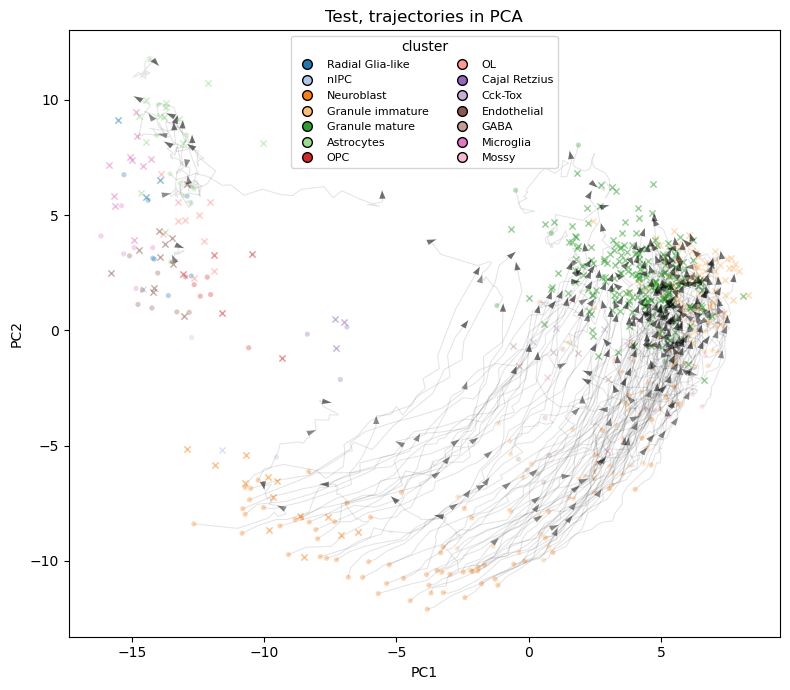

In [29]:
src_clusters_snap_te = cl12_te[:traj_2d_te.shape[1]]

plot_cluster_trajectories_pca(
    src_2d=src_2d_te,
    tgt_2d=tgt_2d_te,
    traj_2d=traj_2d_te,
    src_clusters_all=cl12_te,
    tgt_clusters_all=cl35_te,
    src_clusters_snap=src_clusters_snap_te,
    t_show=t_show_all,
    title="Test, trajectories in PCA",
    min_n=10,
    arrow_frac=(0.5,),
    arrow_every=2,
)

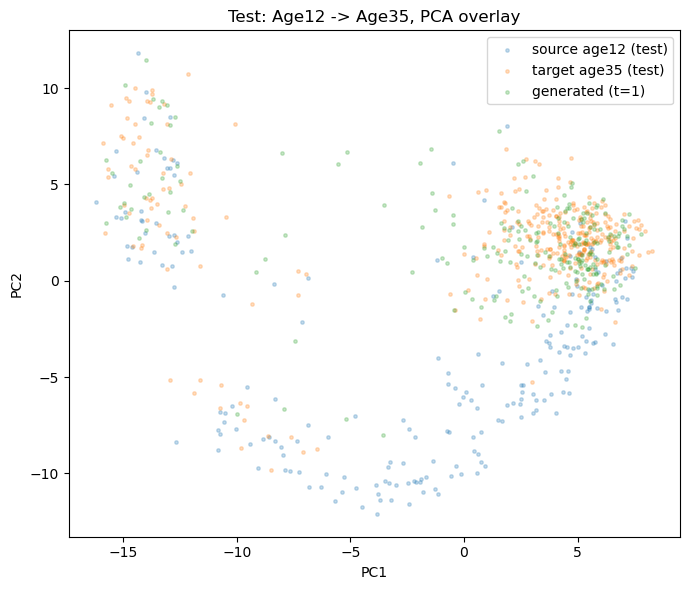

In [30]:
plt.figure(figsize=(7, 6))
plt.scatter(src_2d_te[:, 0], src_2d_te[:, 1], s=6, alpha=0.25, label="source age12 (test)")
plt.scatter(tgt_2d_te[:, 0], tgt_2d_te[:, 1], s=6, alpha=0.25, label="target age35 (test)")
plt.scatter(gen_2d_te[:, 0], gen_2d_te[:, 1], s=6, alpha=0.25, label="generated (t=1)")
plt.title("Test: Age12 -> Age35, PCA overlay")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

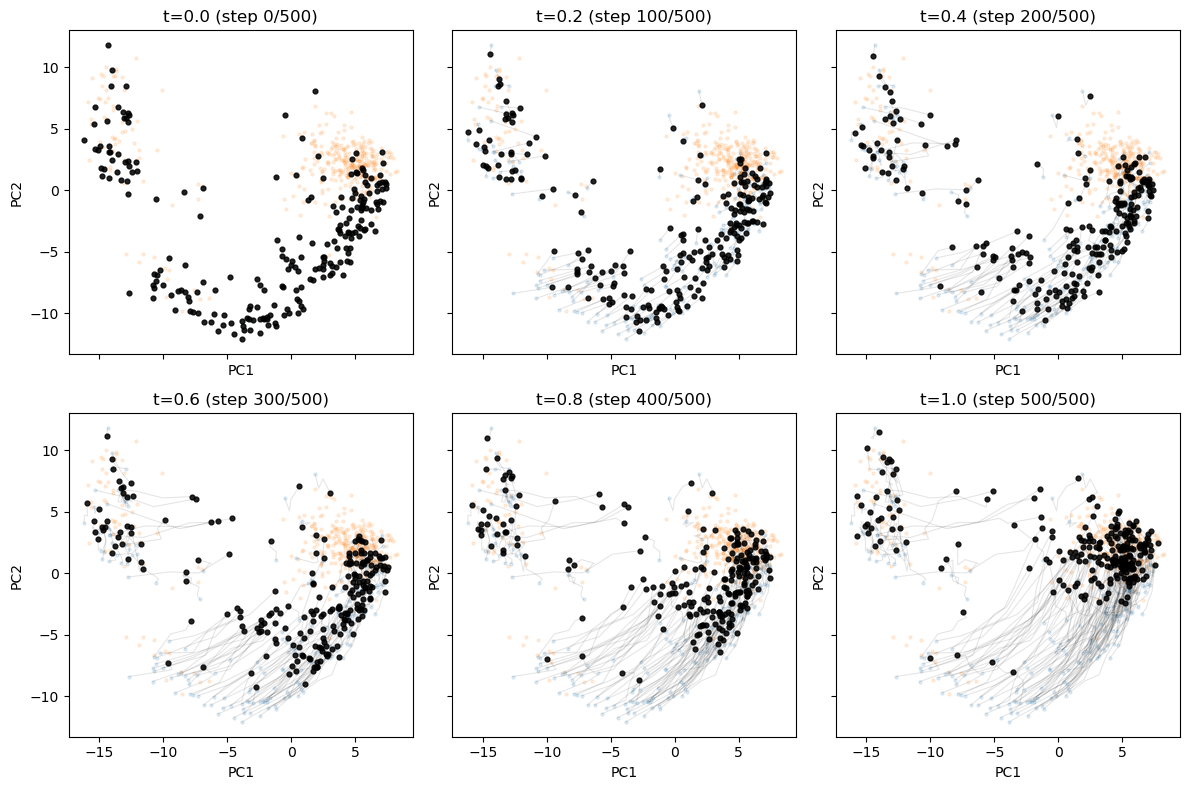

In [31]:
traj_panel_2d_te = proj2_traj(traj_snap_te_panel_counts, pca_top_idx_all, pca_center_all, pca_W_all)
snap_ids_panel = np.clip(np.round(t_show_panel * n_step_eval).astype(int), 0, n_step_eval)

rng = np.random.default_rng(123)
N_tail = min(250, traj_panel_2d_te.shape[1])
idx_tail = rng.choice(traj_panel_2d_te.shape[1], size=N_tail, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()

for j, ax in enumerate(axes):
    ax.scatter(src_2d_te[:, 0], src_2d_te[:, 1], s=5, alpha=0.12, color="tab:blue")
    ax.scatter(tgt_2d_te[:, 0], tgt_2d_te[:, 1], s=5, alpha=0.12, color="tab:orange")
    for i in idx_tail:
        path = traj_panel_2d_te[:j+1, i, :]
        ax.plot(path[:, 0], path[:, 1], color="black", alpha=0.10, linewidth=0.8)
    ax.scatter(traj_panel_2d_te[j, idx_tail, 0], traj_panel_2d_te[j, idx_tail, 1], s=12, alpha=0.85, color="black")
    ax.set_title(f"t={t_show_panel[j]:.1f} (step {snap_ids_panel[j]}/{n_step_eval})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

In [32]:
def knn_assign_clusters(query_2d, ref_2d, ref_clusters, k=15):
    ref_clusters = np.asarray(ref_clusters).astype(str)
    out = []
    k = min(k, len(ref_clusters))
    for i in range(query_2d.shape[0]):
        d2 = ((ref_2d - query_2d[i:i+1]) ** 2).sum(axis=1)
        nn_idx = np.argpartition(d2, k - 1)[:k]
        vote = Counter(ref_clusters[nn_idx]).most_common(1)[0][0]
        out.append(vote)
    return np.asarray(out, dtype=object)

def fate_table(start_clusters, end_clusters):
    tab_n = pd.crosstab(
        pd.Series(start_clusters, name="start"),
        pd.Series(end_clusters, name="end"),
    )
    tab_p = pd.crosstab(
        pd.Series(start_clusters, name="start"),
        pd.Series(end_clusters, name="end"),
        normalize="index",
    )
    return tab_n, tab_p

In [33]:
end_cl_tr = knn_assign_clusters(
    query_2d=gen_2d_tr,
    ref_2d=ref_2d_all,
    ref_clusters=ref_clusters_all,
    k=10,
)

tab_train_n, tab_train_p = fate_table(cl12_tr, end_cl_tr)

# print("Train, counts")
# display(tab_train_n)

# print("Train, row proportions")
# display(tab_train_p.round(3))

In [34]:
end_cl_te = knn_assign_clusters(
    query_2d=gen_2d_te,
    ref_2d=ref_2d_all,
    ref_clusters=ref_clusters_all,
    k=10,
)

tab_test_n, tab_test_p = fate_table(cl12_te, end_cl_te)

# print("Test, counts")
# display(tab_test_n)

# print("Test, row proportions")
# display(tab_test_p.round(3))

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def prepare_fate_heatmaps(
    tab_train_n,
    tab_train_p,
    tab_test_n,
    tab_test_p,
    min_start_n=20,
    min_prop=0.05,
):
    # union rows / cols first
    all_rows = sorted(set(tab_train_p.index) | set(tab_test_p.index))
    all_cols = sorted(set(tab_train_p.columns) | set(tab_test_p.columns))

    tr_n = tab_train_n.reindex(index=all_rows, columns=all_cols, fill_value=0)
    te_n = tab_test_n.reindex(index=all_rows, columns=all_cols, fill_value=0)
    tr_p = tab_train_p.reindex(index=all_rows, columns=all_cols, fill_value=0.0)
    te_p = tab_test_p.reindex(index=all_rows, columns=all_cols, fill_value=0.0)

    # keep source clusters with enough starting cells in either split
    start_n_tr = tr_n.sum(axis=1)
    start_n_te = te_n.sum(axis=1)
    keep_rows = (start_n_tr >= min_start_n) | (start_n_te >= min_start_n)

    # keep end fates that get enough mass in either split
    keep_cols = (tr_p.max(axis=0) >= min_prop) | (te_p.max(axis=0) >= min_prop)

    # biological order
    ordered = _cluster_order_present(all_rows + all_cols)

    row_order = [x for x in ordered if x in tr_p.index and keep_rows.get(x, False)]
    col_order = [x for x in ordered if x in tr_p.columns and keep_cols.get(x, False)]

    tr_n = tr_n.loc[row_order, col_order]
    te_n = te_n.loc[row_order, col_order]
    tr_p = tr_p.loc[row_order, col_order]
    te_p = te_p.loc[row_order, col_order]

    return tr_n, tr_p, te_n, te_p

def plot_fate_heatmaps(
    tab_train_p,
    tab_test_p,
    title_train="Train, inferred fate proportions",
    title_test="Test, inferred fate proportions",
    annotate=True,
    figsize=(14, 5),
):
    vmax = max(float(tab_train_p.to_numpy().max()), float(tab_test_p.to_numpy().max()))
    vmax = max(vmax, 0.2)

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True, constrained_layout=True)

    ims = []
    for ax, tab, ttl in zip(axes, [tab_train_p, tab_test_p], [title_train, title_test]):
        im = ax.imshow(tab.values, aspect="auto", vmin=0.0, vmax=vmax)
        ims.append(im)

        ax.set_xticks(range(tab.shape[1]))
        ax.set_xticklabels(tab.columns, rotation=45, ha="right")
        ax.set_yticks(range(tab.shape[0]))
        ax.set_yticklabels(tab.index)

        ax.set_xlabel("end cluster (age = 35)")
        ax.set_ylabel("start cluster (age = 12)")
        ax.set_title(ttl)

        if annotate:
            for i in range(tab.shape[0]):
                for j in range(tab.shape[1]):
                    val = tab.iat[i, j]
                    if val <= 0:
                        continue
                    txt_color = "white" if val > 0.5 * vmax else "black"
                    ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=txt_color)

    cbar = fig.colorbar(ims[0], ax=axes, location="right", shrink=0.92, pad=0.02)
    cbar.set_label("row proportion")

    plt.show()

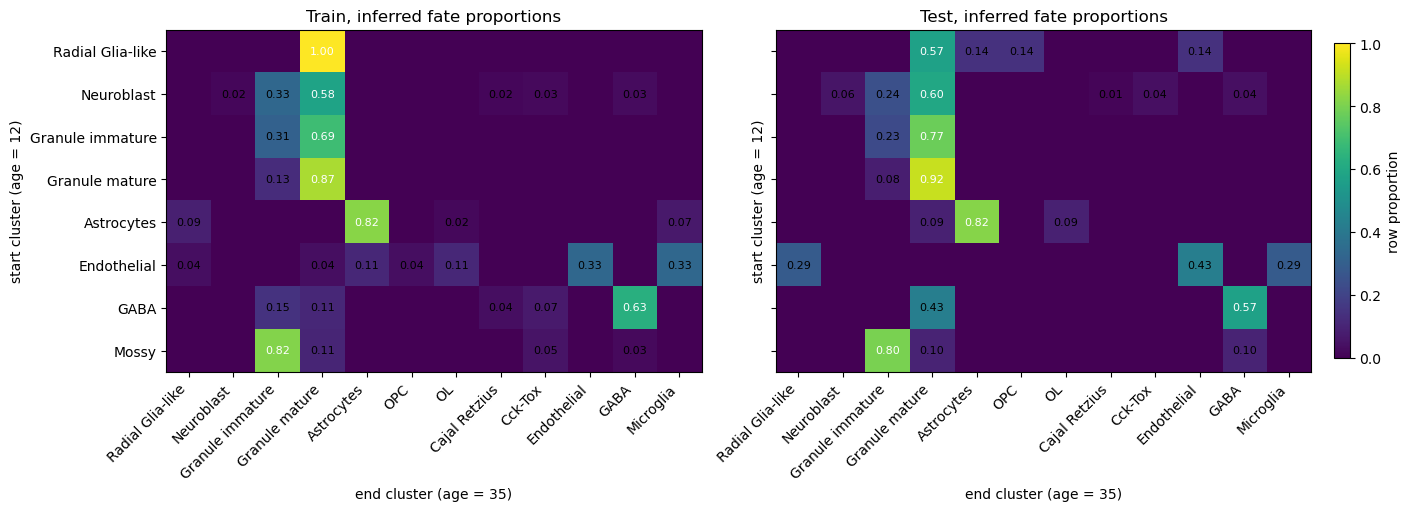

In [36]:
tr_n_hm, tr_p_hm, te_n_hm, te_p_hm = prepare_fate_heatmaps(
    tab_train_n=tab_train_n,
    tab_train_p=tab_train_p,
    tab_test_n=tab_test_n,
    tab_test_p=tab_test_p,
    min_start_n=25,   # source clusters with enough cells
    min_prop=0.05,    # end fates with enough mass
)

# print("Train heatmap table")
# display(tr_p_hm.round(2))

# print("Test heatmap table")
# display(te_p_hm.round(2))

plot_fate_heatmaps(
    tab_train_p=tr_p_hm,
    tab_test_p=te_p_hm,
    title_train="Train, inferred fate proportions",
    title_test="Test, inferred fate proportions",
    annotate=True,
)

# Output Figures

In [37]:
import os

FIG_DIR = "figures_paper"
os.makedirs(FIG_DIR, exist_ok=True)

def plot_cluster_trajectories_pca_ax(
    ax,
    src_2d,
    tgt_2d,
    traj_2d,
    src_clusters_all,
    tgt_clusters_all,
    src_clusters_snap,
    title,
    cluster_order=None,
    color_map=None,
    min_n=20,
    traj_alpha=0.10,
    traj_lw=0.8,
    arrow_alpha=0.55,
    arrow_frac=(0.70,),
    arrow_every=3,
    endpoint_arrow=True,
    head_len=0.35,
    head_w=0.12,
):
    src_clusters_all = pd.Series(src_clusters_all).astype(str).values
    tgt_clusters_all = pd.Series(tgt_clusters_all).astype(str).values
    src_clusters_snap = pd.Series(src_clusters_snap).astype(str).values

    if cluster_order is None:
        cluster_order = _cluster_order_present(
            np.concatenate([src_clusters_all, tgt_clusters_all, src_clusters_snap])
        )

    if color_map is None:
        cmap = plt.get_cmap("tab20")
        color_map = {k: cmap(i % 20) for i, k in enumerate(cluster_order)}

    for k in cluster_order:
        src_idx = (src_clusters_all == k)
        tgt_idx = (tgt_clusters_all == k)

        if src_idx.sum() > 0:
            ax.scatter(
                src_2d[src_idx, 0],
                src_2d[src_idx, 1],
                s=14,
                alpha=0.32,
                color=color_map[k],
                edgecolors="none",
            )

        if tgt_idx.sum() > 0:
            ax.scatter(
                tgt_2d[tgt_idx, 0],
                tgt_2d[tgt_idx, 1],
                s=20,
                alpha=0.50,
                color=color_map[k],
                marker="x",
                linewidths=1.0,
            )

    T = traj_2d.shape[0]

    inner_steps = []
    for frac in arrow_frac:
        s = int(round(frac * (T - 1)))
        s = max(1, min(T - 1, s))
        inner_steps.append(s)
    inner_steps = sorted(set(inner_steps))

    def _draw_arrowhead_only(ax, p0, p1, alpha, head_len, head_w):
        x0, y0 = p0
        x1, y1 = p1
        dx = x1 - x0
        dy = y1 - y0
        norm = np.hypot(dx, dy)
        if norm < 1e-12:
            return

        ux, uy = dx / norm, dy / norm
        px, py = -uy, ux

        tip = np.array([x1, y1])
        base = tip - head_len * np.array([ux, uy])
        left = base + head_w * np.array([px, py])
        right = base - head_w * np.array([px, py])

        patch = Polygon(
            [tip, left, right],
            closed=True,
            facecolor="black",
            edgecolor="none",
            alpha=alpha,
            zorder=4,
        )
        ax.add_patch(patch)

    for k in cluster_order:
        idx = np.where(src_clusters_snap == k)[0]
        if len(idx) < min_n:
            continue

        for m, j in enumerate(idx):
            path = traj_2d[:, j, :]

            ax.plot(
                path[:, 0],
                path[:, 1],
                color="black",
                alpha=traj_alpha,
                linewidth=traj_lw,
            )

            if (m % arrow_every) == 0:
                for s in inner_steps:
                    _draw_arrowhead_only(
                        ax,
                        path[s - 1],
                        path[s],
                        alpha=arrow_alpha * 0.8,
                        head_len=head_len,
                        head_w=head_w,
                    )

            if endpoint_arrow and T >= 2:
                _draw_arrowhead_only(
                    ax,
                    path[-2],
                    path[-1],
                    alpha=arrow_alpha,
                    head_len=head_len,
                    head_w=head_w,
                )

    handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=color_map[k],
            markeredgecolor="black",
            markersize=7,
            label=k,
        )
        for k in cluster_order
    ]

    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    return handles, cluster_order, color_map

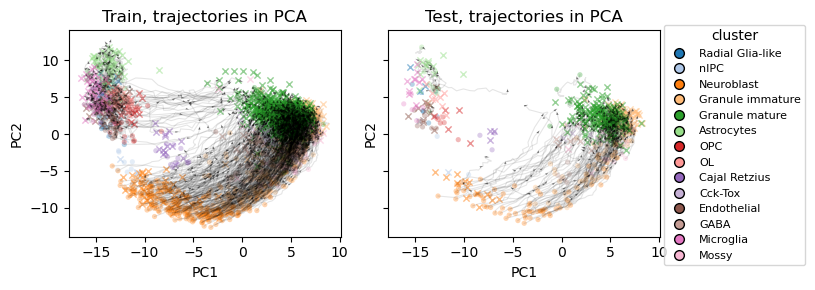

In [54]:
src_clusters_snap_tr = cl12_tr[:traj_2d_tr.shape[1]]
src_clusters_snap_te = cl12_te[:traj_2d_te.shape[1]]

cluster_order_shared = _cluster_order_present(
    np.concatenate([
        cl12_tr, cl35_tr, src_clusters_snap_tr,
        cl12_te, cl35_te, src_clusters_snap_te
    ])
)
cmap = plt.get_cmap("tab20")
color_map_shared = {k: cmap(i % 20) for i, k in enumerate(cluster_order_shared)}

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharex=True, sharey=True)

handles, _, _ = plot_cluster_trajectories_pca_ax(
    ax=axes[0],
    src_2d=src_2d_tr,
    tgt_2d=tgt_2d_tr,
    traj_2d=traj_2d_tr,
    src_clusters_all=cl12_tr,
    tgt_clusters_all=cl35_tr,
    src_clusters_snap=src_clusters_snap_tr,
    title="Train, trajectories in PCA",
    cluster_order=cluster_order_shared,
    color_map=color_map_shared,
    min_n=20,
    arrow_frac=(0.5,),
    arrow_every=2,
)

plot_cluster_trajectories_pca_ax(
    ax=axes[1],
    src_2d=src_2d_te,
    tgt_2d=tgt_2d_te,
    traj_2d=traj_2d_te,
    src_clusters_all=cl12_te,
    tgt_clusters_all=cl35_te,
    src_clusters_snap=src_clusters_snap_te,
    title="Test, trajectories in PCA",
    cluster_order=cluster_order_shared,
    color_map=color_map_shared,
    min_n=10,
    arrow_frac=(0.5,),
    arrow_every=2,
)

fig.legend(
    handles=handles,
    loc="center right",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=8,
    ncol=1,
    title="cluster",
)

plt.tight_layout(rect=[0, 0, 0.86, 1])
fig.savefig(
    os.path.join(FIG_DIR, "scRNA_age_OT_pca_train_test_traj.pdf"),
    format="pdf",
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

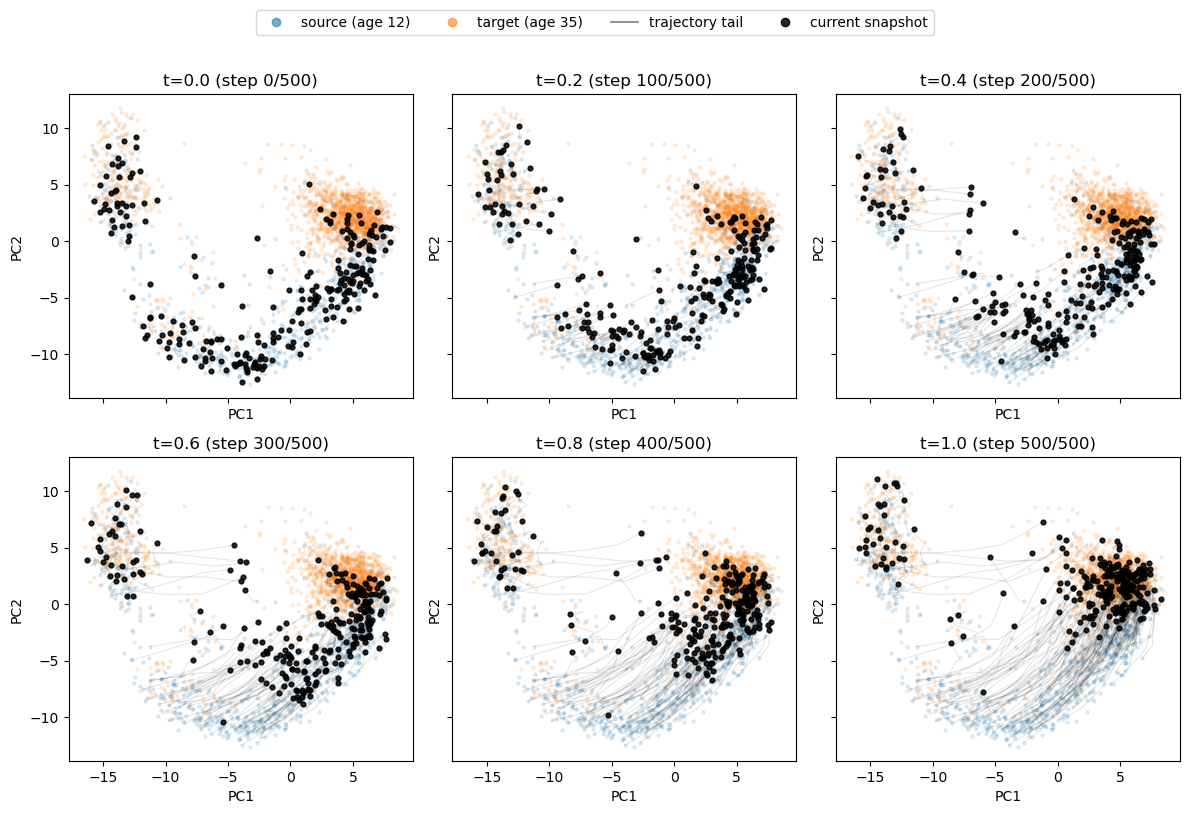

In [47]:
traj_panel_2d_tr = proj2_traj(traj_snap_tr_panel_counts, pca_top_idx_all, pca_center_all, pca_W_all)
snap_ids_panel = np.clip(np.round(t_show_panel * n_step_eval).astype(int), 0, n_step_eval)

rng = np.random.default_rng(123)
N_tail = min(250, traj_panel_2d_tr.shape[1])
idx_tail = rng.choice(traj_panel_2d_tr.shape[1], size=N_tail, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()

for j, ax in enumerate(axes):
    ax.scatter(src_2d_tr[:, 0], src_2d_tr[:, 1], s=5, alpha=0.12, color="tab:blue")
    ax.scatter(tgt_2d_tr[:, 0], tgt_2d_tr[:, 1], s=5, alpha=0.12, color="tab:orange")
    for i in idx_tail:
        path = traj_panel_2d_tr[:j+1, i, :]
        ax.plot(path[:, 0], path[:, 1], color="black", alpha=0.10, linewidth=0.8)
    ax.scatter(
        traj_panel_2d_tr[j, idx_tail, 0],
        traj_panel_2d_tr[j, idx_tail, 1],
        s=12, alpha=0.85, color="black"
    )
    ax.set_title(f"t={t_show_panel[j]:.1f} (step {snap_ids_panel[j]}/{n_step_eval})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

legend_handles = [
    Line2D([0], [0], marker="o", linestyle="None", color="tab:blue",
           markersize=6, alpha=0.6, label="source (age 12)"),
    Line2D([0], [0], marker="o", linestyle="None", color="tab:orange",
           markersize=6, alpha=0.6, label="target (age 35)"),
    Line2D([0], [0], color="black", lw=1.2, alpha=0.5, label="trajectory tail"),
    Line2D([0], [0], marker="o", linestyle="None", color="black",
           markersize=6, alpha=0.85, label="current snapshot"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.02),
    frameon=True,
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(
    os.path.join(FIG_DIR, "scRNA_age_OT_trace_train.pdf"),
    format="pdf",
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

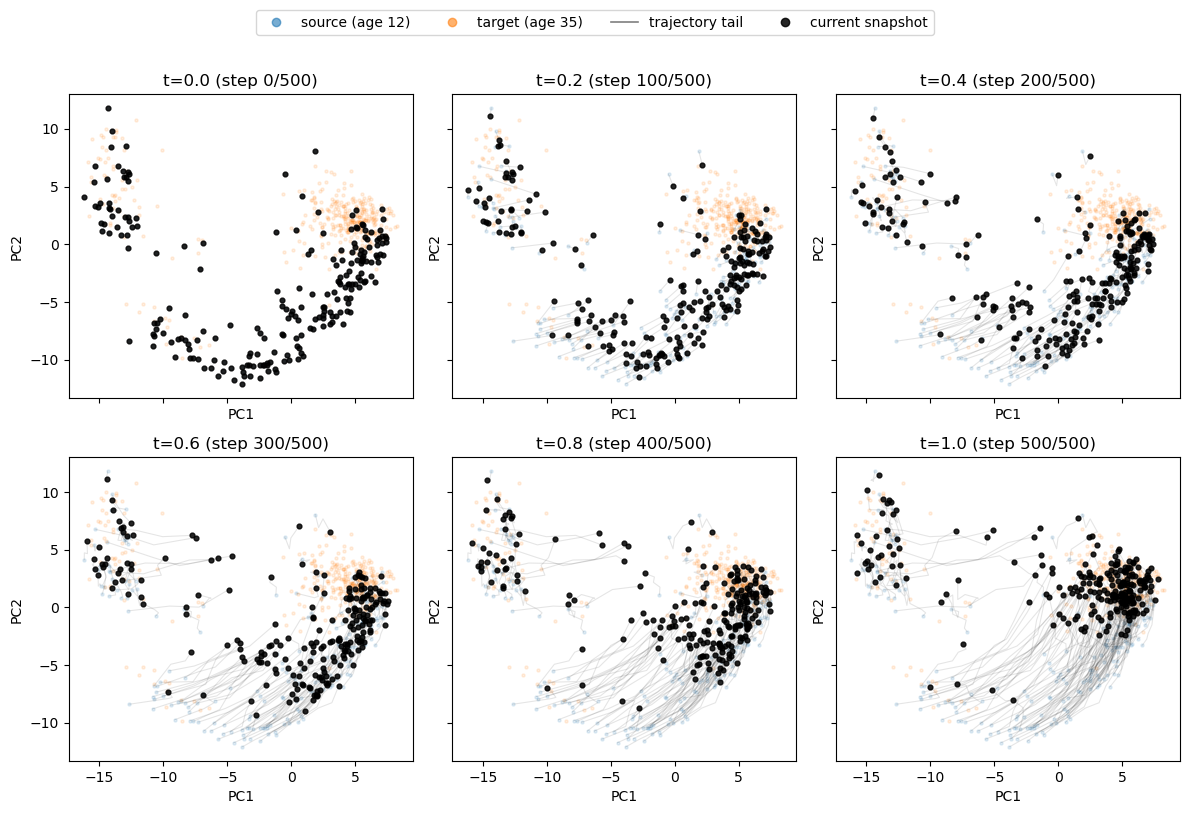

In [48]:
traj_panel_2d_te = proj2_traj(traj_snap_te_panel_counts, pca_top_idx_all, pca_center_all, pca_W_all)
snap_ids_panel = np.clip(np.round(t_show_panel * n_step_eval).astype(int), 0, n_step_eval)

rng = np.random.default_rng(123)
N_tail = min(250, traj_panel_2d_te.shape[1])
idx_tail = rng.choice(traj_panel_2d_te.shape[1], size=N_tail, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()

for j, ax in enumerate(axes):
    ax.scatter(src_2d_te[:, 0], src_2d_te[:, 1], s=5, alpha=0.12, color="tab:blue")
    ax.scatter(tgt_2d_te[:, 0], tgt_2d_te[:, 1], s=5, alpha=0.12, color="tab:orange")
    for i in idx_tail:
        path = traj_panel_2d_te[:j+1, i, :]
        ax.plot(path[:, 0], path[:, 1], color="black", alpha=0.10, linewidth=0.8)
    ax.scatter(
        traj_panel_2d_te[j, idx_tail, 0],
        traj_panel_2d_te[j, idx_tail, 1],
        s=12, alpha=0.85, color="black"
    )
    ax.set_title(f"t={t_show_panel[j]:.1f} (step {snap_ids_panel[j]}/{n_step_eval})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

legend_handles = [
    Line2D([0], [0], marker="o", linestyle="None", color="tab:blue",
           markersize=6, alpha=0.6, label="source (age 12)"),
    Line2D([0], [0], marker="o", linestyle="None", color="tab:orange",
           markersize=6, alpha=0.6, label="target (age 35)"),
    Line2D([0], [0], color="black", lw=1.2, alpha=0.5, label="trajectory tail"),
    Line2D([0], [0], marker="o", linestyle="None", color="black",
           markersize=6, alpha=0.85, label="current snapshot"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.02),
    frameon=True,
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(
    os.path.join(FIG_DIR, "scRNA_age_OT_trace_test.pdf"),
    format="pdf",
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

In [41]:
def prepare_fate_heatmaps(
    tab_train_n,
    tab_train_p,
    tab_test_n,
    tab_test_p,
    min_start_n=20,
    min_prop=0.05,
):
    all_rows = sorted(set(tab_train_p.index) | set(tab_test_p.index))
    all_cols = sorted(set(tab_train_p.columns) | set(tab_test_p.columns))

    tr_n = tab_train_n.reindex(index=all_rows, columns=all_cols, fill_value=0)
    te_n = tab_test_n.reindex(index=all_rows, columns=all_cols, fill_value=0)
    tr_p = tab_train_p.reindex(index=all_rows, columns=all_cols, fill_value=0.0)
    te_p = tab_test_p.reindex(index=all_rows, columns=all_cols, fill_value=0.0)

    start_n_tr = tr_n.sum(axis=1)
    start_n_te = te_n.sum(axis=1)
    keep_rows = (start_n_tr >= min_start_n) | (start_n_te >= min_start_n)

    keep_cols = (tr_p.max(axis=0) >= min_prop) | (te_p.max(axis=0) >= min_prop)

    ordered = _cluster_order_present(all_rows + all_cols)

    row_order = [x for x in ordered if x in tr_p.index and keep_rows.get(x, False)]
    col_order = [x for x in ordered if x in tr_p.columns and keep_cols.get(x, False)]

    tr_n = tr_n.loc[row_order, col_order]
    te_n = te_n.loc[row_order, col_order]
    tr_p = tr_p.loc[row_order, col_order]
    te_p = te_p.loc[row_order, col_order]

    return tr_n, tr_p, te_n, te_p

def plot_fate_heatmaps(
    tab_train_p,
    tab_test_p,
    title_train="Train, inferred fate proportions",
    title_test="Test, inferred fate proportions",
    annotate=True,
    figsize=(14, 5),
):
    vmax = max(float(tab_train_p.to_numpy().max()), float(tab_test_p.to_numpy().max()))
    vmax = max(vmax, 0.2)

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True, constrained_layout=True)

    ims = []
    for ax, tab, ttl in zip(axes, [tab_train_p, tab_test_p], [title_train, title_test]):
        im = ax.imshow(tab.values, aspect="auto", vmin=0.0, vmax=vmax)
        ims.append(im)

        ax.set_xticks(range(tab.shape[1]))
        ax.set_xticklabels(tab.columns, rotation=45, ha="right")
        ax.set_yticks(range(tab.shape[0]))
        ax.set_yticklabels(tab.index)

        ax.set_xlabel("end cluster (age = 35)")
        ax.set_ylabel("start cluster (age = 12)")
        ax.set_title(ttl)

        if annotate:
            for i in range(tab.shape[0]):
                for j in range(tab.shape[1]):
                    val = tab.iat[i, j]
                    if val <= 0:
                        continue
                    txt_color = "white" if val > 0.5 * vmax else "black"
                    ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=txt_color)

    cbar = fig.colorbar(ims[0], ax=axes, location="right", shrink=0.92, pad=0.02)
    cbar.set_label("row proportion")

    return fig, axes

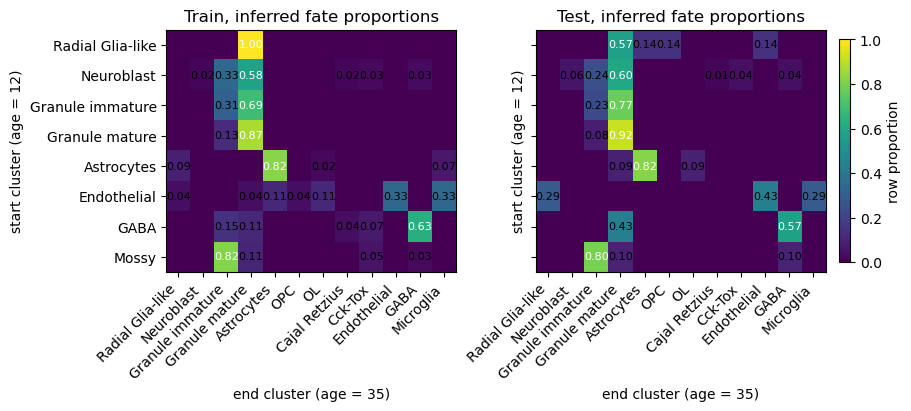

In [51]:
tr_n_hm, tr_p_hm, te_n_hm, te_p_hm = prepare_fate_heatmaps(
    tab_train_n=tab_train_n,
    tab_train_p=tab_train_p,
    tab_test_n=tab_test_n,
    tab_test_p=tab_test_p,
    min_start_n=25,
    min_prop=0.05,
)

# print("Train heatmap table")
# display(tr_p_hm.round(2))

# print("Test heatmap table")
# display(te_p_hm.round(2))

fig, axes = plot_fate_heatmaps(
    tab_train_p=tr_p_hm,
    tab_test_p=te_p_hm,
    title_train="Train, inferred fate proportions",
    title_test="Test, inferred fate proportions",
    annotate=True,
    figsize=(9, 4)
)

fig.savefig(
    os.path.join(FIG_DIR, "scRNA_age_OT_fate_prop_train_test.pdf"),
    format="pdf",
    bbox_inches="tight",
)
plt.show()
plt.close(fig)